# Modelo de Clasificación — Síndrome de Ovario Poliquístico (SOP / PCOS)

**Dataset:** `SOP_clean.csv` — 541 registros, columnas clínicas y síntomas  
**Target:** `PCOS (Y/N)` — 0 = sin SOP, 1 = con SOP  
**Desbalance aproximado:** 2:1 (más negativos que positivos)  
**Validación principal:** StratifiedKFold (n=5) por el tamaño pequeño del dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, train_test_split
)
from sklearn.metrics import (
    classification_report, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings('ignore')

# ── Cambia esta ruta si mueves el CSV ──────────────────────────────────────
CSV_PATH = 'SOP_clean.csv'
TARGET   = 'PCOS (Y/N)'
# ──────────────────────────────────────────────────────────────────────────

df = pd.read_csv(CSV_PATH)

print('Shape:', df.shape)
print('\nDtypes:')
print(df.dtypes)
print('\nDistribución del target:')
print(df[TARGET].value_counts())
print('\nProporción:')
print(df[TARGET].value_counts(normalize=True).round(3))

Shape: (541, 42)

Dtypes:
PCOS (Y/N)                  int64
 Age (yrs)                  int64
Weight (Kg)               float64
Height(Cm)                float64
BMI                       float64
Blood Group                 int64
Pulse rate(bpm)             int64
RR (breaths/min)            int64
Hb(g/dl)                  float64
Cycle(R/I)                  int64
Cycle length(days)          int64
Marraige Status (Yrs)     float64
Pregnant(Y/N)               int64
No. of aborptions           int64
  I   beta-HCG(mIU/mL)    float64
II    beta-HCG(mIU/mL)    float64
FSH(mIU/mL)               float64
LH(mIU/mL)                float64
FSH/LH                    float64
Hip(inch)                   int64
Waist(inch)                 int64
Waist:Hip Ratio           float64
TSH (mIU/L)               float64
AMH(ng/mL)                float64
PRL(ng/mL)                float64
Vit D3 (ng/mL)            float64
PRG(ng/mL)                float64
RBS(mg/dl)                float64
Weight gain(Y/N)      

In [2]:
nulos = df.isnull().sum()
print('Nulos por columna:')
print(nulos[nulos > 0] if nulos.any() else 'Sin valores nulos ✓')

Nulos por columna:
Sin valores nulos ✓


## dividir train y test

In [3]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

print('Features:', X.shape[1])
print('Ejemplos:', X.shape[0])

# Validación cruzada estratificada — método principal
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Split para evaluación final
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'\nTrain: {X_train.shape[0]} muestras | Test: {X_test.shape[0]} muestras')
print('Distribución en train:')
print(y_train.value_counts())
print('Distribución en test:')
print(y_test.value_counts())

Features: 41
Ejemplos: 541

Train: 432 muestras | Test: 109 muestras
Distribución en train:
PCOS (Y/N)
0    291
1    141
Name: count, dtype: int64
Distribución en test:
PCOS (Y/N)
0    73
1    36
Name: count, dtype: int64


## pipeline

In [4]:
pipeline_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(
                    n_estimators=100,
                    class_weight='balanced',
                    random_state=42
               ))
])

print('Pipeline RF:')
print(pipeline_rf)

Pipeline RF:
Pipeline(steps=[('scaler', StandardScaler()),
                ('clf',
                 RandomForestClassifier(class_weight='balanced',
                                        random_state=42))])


## Validación cruzada con StratifiedKFold

In [5]:
scores_rf = cross_val_score(
    pipeline_rf, X, y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print('AUC-ROC por fold (Random Forest):')
for i, s in enumerate(scores_rf, 1):
    print(f'  Fold {i}: {s:.4f}')

print(f'\nMedia:  {scores_rf.mean():.4f}')
print(f'Desvío: {scores_rf.std():.4f}')

AUC-ROC por fold (Random Forest):
  Fold 1: 0.9519
  Fold 2: 0.9481
  Fold 3: 0.9683
  Fold 4: 0.9783
  Fold 5: 0.9610

Media:  0.9615
Desvío: 0.0109


## Baseline de comparación (Logistic Regression)


In [6]:
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('clf',    LogisticRegression(
                    class_weight='balanced',
                    max_iter=1000,
                    random_state=42
               ))
])

scores_lr = cross_val_score(
    pipeline_lr, X, y,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print('AUC-ROC por fold (Logistic Regression):')
for i, s in enumerate(scores_lr, 1):
    print(f'  Fold {i}: {s:.4f}')

print(f'\nMedia:  {scores_lr.mean():.4f}')
print(f'Desvío: {scores_lr.std():.4f}')

AUC-ROC por fold (Logistic Regression):
  Fold 1: 0.9391
  Fold 2: 0.9448
  Fold 3: 0.9444
  Fold 4: 0.9331
  Fold 5: 0.9406

Media:  0.9404
Desvío: 0.0043


Comparación de modelos (StratifiedKFold, 5 folds):
             Modelo  AUC Media  AUC Std
      Random Forest   0.961523 0.010947
Logistic Regression   0.940403 0.004267


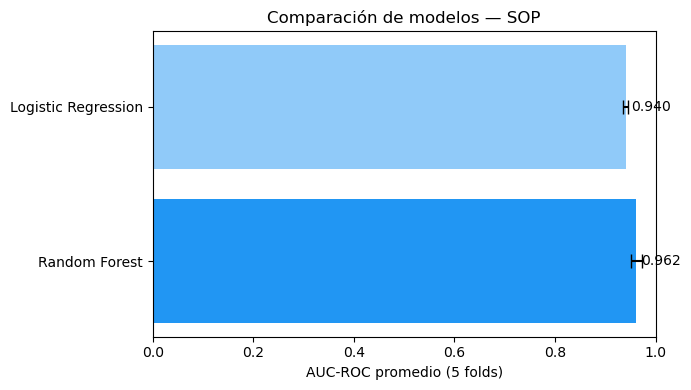

In [7]:
comparacion = pd.DataFrame({
    'Modelo':   ['Random Forest', 'Logistic Regression'],
    'AUC Media': [scores_rf.mean(), scores_lr.mean()],
    'AUC Std':   [scores_rf.std(),  scores_lr.std()]
})
comparacion = comparacion.sort_values('AUC Media', ascending=False).reset_index(drop=True)

print('Comparación de modelos (StratifiedKFold, 5 folds):')
print(comparacion.to_string(index=False))

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(
    comparacion['Modelo'],
    comparacion['AUC Media'],
    xerr=comparacion['AUC Std'],
    color=['#2196F3', '#90CAF9'],
    capsize=5
)
ax.set_xlim(0, 1)
ax.set_xlabel('AUC-ROC promedio (5 folds)')
ax.set_title('Comparación de modelos — SOP')
for bar, val in zip(bars, comparacion['AUC Media']):
    ax.text(val + 0.01, bar.get_y() + bar.get_height() / 2,
            f'{val:.3f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

## fit, y evaluacion

In [8]:
# Entrenamiento final sobre el train set completo
pipeline_rf.fit(X_train, y_train)

y_pred      = pipeline_rf.predict(X_test)
y_pred_prob = pipeline_rf.predict_proba(X_test)[:, 1]

print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Sin SOP (0)', 'Con SOP (1)']))

recall_positivo = classification_report(
    y_test, y_pred, output_dict=True
)['1']['recall']
auc_final = roc_auc_score(y_test, y_pred_prob)

print(f'Recall clase PCOS=1 : {recall_positivo:.4f}')
print(f'AUC-ROC (test set)  : {auc_final:.4f}')

Classification Report:
              precision    recall  f1-score   support

 Sin SOP (0)       0.91      0.97      0.94        73
 Con SOP (1)       0.94      0.81      0.87        36

    accuracy                           0.92       109
   macro avg       0.92      0.89      0.90       109
weighted avg       0.92      0.92      0.92       109

Recall clase PCOS=1 : 0.8056
AUC-ROC (test set)  : 0.9342


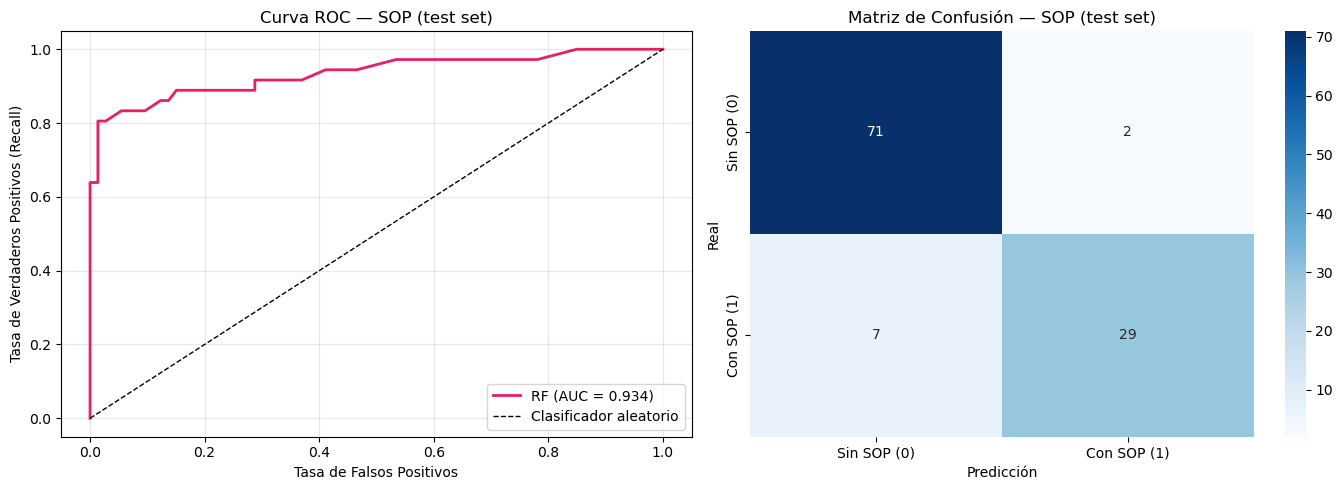

In [9]:
# ── Curva ROC ──────────────────────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_prob)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Curva ROC
axes[0].plot(fpr, tpr, color='#E91E63', lw=2,
             label=f'RF (AUC = {auc_final:.3f})')
axes[0].plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio')
axes[0].set_xlabel('Tasa de Falsos Positivos')
axes[0].set_ylabel('Tasa de Verdaderos Positivos (Recall)')
axes[0].set_title('Curva ROC — SOP (test set)')
axes[0].legend(loc='lower right')
axes[0].grid(alpha=0.3)

# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Sin SOP (0)', 'Con SOP (1)'],
    yticklabels=['Sin SOP (0)', 'Con SOP (1)'],
    ax=axes[1]
)
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')
axes[1].set_title('Matriz de Confusión — SOP (test set)')

plt.tight_layout()
plt.show()

## Feature Importance (Random Forest)

In [10]:
rf_model   = pipeline_rf.named_steps['clf']
importances = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print('Top 15 features por importancia:')
print(importances.head(15).round(4))

Top 15 features por importancia:
Follicle No. (R)        0.2041
Follicle No. (L)        0.1203
Weight gain(Y/N)        0.0586
Skin darkening (Y/N)    0.0542
hair growth(Y/N)        0.0450
AMH(ng/mL)              0.0369
Cycle length(days)      0.0291
Cycle(R/I)              0.0254
BMI                     0.0234
Weight (Kg)             0.0212
 Age (yrs)              0.0207
LH(mIU/mL)              0.0195
FSH/LH                  0.0189
Endometrium (mm)        0.0183
Vit D3 (ng/mL)          0.0169
dtype: float64


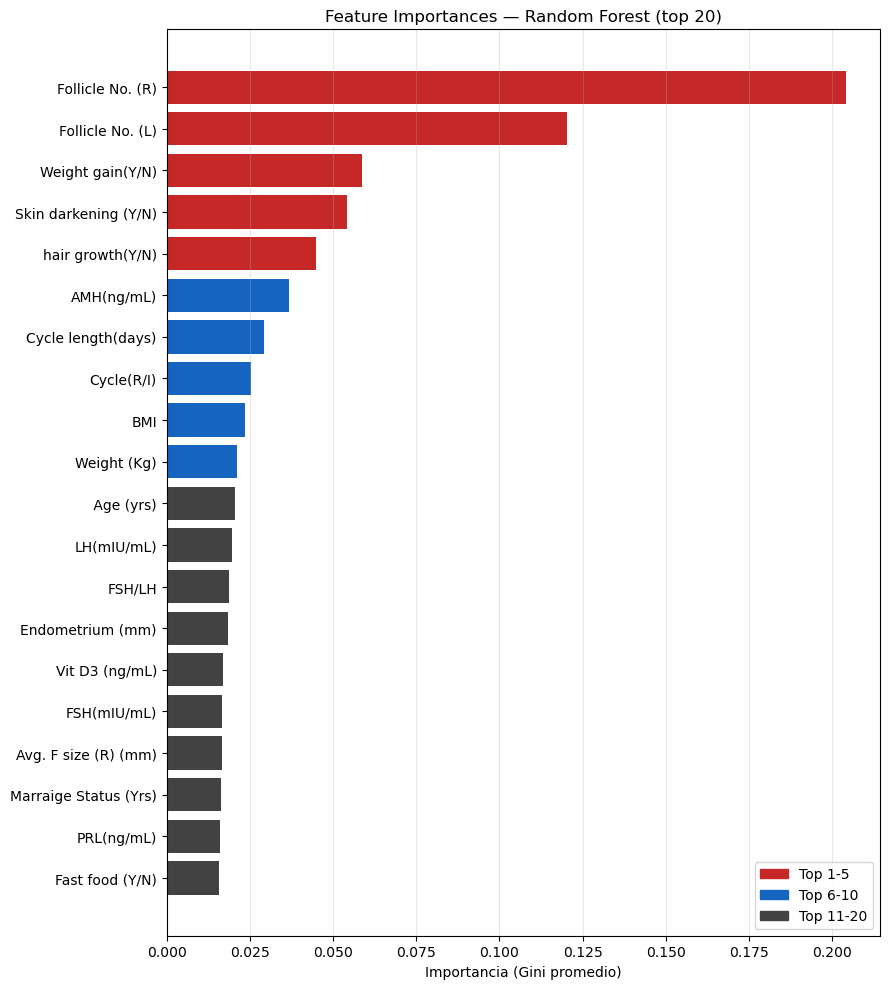


Variables con mayor peso (top 5):
  Follicle No. (R)                         0.2041
  Follicle No. (L)                         0.1203
  Weight gain(Y/N)                         0.0586
  Skin darkening (Y/N)                     0.0542
  hair growth(Y/N)                         0.0450


In [11]:
n_top = min(20, len(importances))
top_features = importances.head(n_top)

fig, ax = plt.subplots(figsize=(9, n_top * 0.45 + 1))

colors = ['#C62828' if i < 5 else '#1565C0' if i < 10 else '#424242'
          for i in range(n_top)]

ax.barh(
    top_features.index[::-1],
    top_features.values[::-1],
    color=colors[::-1]
)
ax.set_xlabel('Importancia (Gini promedio)')
ax.set_title(f'Feature Importances — Random Forest (top {n_top})')
ax.grid(axis='x', alpha=0.3)

from matplotlib.patches import Patch
legend_elements = [
    Patch(color='#C62828', label='Top 1-5'),
    Patch(color='#1565C0', label='Top 6-10'),
    Patch(color='#424242', label='Top 11-20'),
]
ax.legend(handles=legend_elements, loc='lower right')

plt.tight_layout()
plt.show()

print('\nVariables con mayor peso (top 5):')
for name, val in importances.head(5).items():
    print(f'  {name:<40} {val:.4f}')